# Testing the cosmic history evolution in the presence of vacuum energy density + radiation

### $\rho = \rho_V + \rho_R$

In [1]:
import sys
sys.path.append("../")

import matplotlib.pyplot as plt

# from pypt.cosmology_functions import *
from pypt.vac_rad_cosmic_history import *
from pypt.vac_rad_cosmic_history_dT_dt import *

In [2]:
E_fixed = 1/16
D_fixed = 2.725

v_I = 1.0
v_II = 10.0
v_III = 50.0

C_by_v_I = 0.1052
C_by_v_II = 0.1040
C_by_v_III = 0.1037

def lambda_coupling(C_by_v):
    return 1.5 * C_by_v + (1/8)


veff_I = VEffGeneric(a=E_fixed, lam=lambda_coupling(C_by_v_I), c=v_I*C_by_v_I, d=D_fixed, vev=v_I, verbose=True)

rhoV_I = veff_I.vev**4 * ((1/8) - 0.5*veff_I.c/veff_I.vev) / 4

veff_II = VEffGeneric(a=E_fixed, lam=lambda_coupling(C_by_v_II), c=v_II*C_by_v_II, d=D_fixed, vev=v_II, verbose=True)

rhoV_II = veff_II.vev**4 * ((1/8) - 0.5*veff_II.c/veff_II.vev) / 4

veff_III = VEffGeneric(a=E_fixed, lam=lambda_coupling(C_by_v_III), c=v_III*C_by_v_III, d=D_fixed, vev=v_III, verbose=True)

rhoV_III = veff_III.vev**4 * ((1/8) - 0.5*veff_III.c/veff_III.vev) / 4

VEV = 1.0, T0^2=-0.00601834862385321
VEV = 10.0, T0^2=-0.5688073394495415
VEV = 50.0, T0^2=-14.013761467889928


In [3]:
chistory = CosmicHistoryVacuumRadiation(vw=1.0, veff=veff_I)
chistory2 = CosmicHistoryVacuumRadiation(vw=1.0, veff=veff_II)
chistory3 = CosmicHistoryVacuumRadiation(vw=1.0, veff=veff_III)

chistory_ = CosmicHistoryVacuumRadiation_dT_dt(vw=1.0, Veff=veff_I)
chistory2_ = CosmicHistoryVacuumRadiation_dT_dt(vw=1.0, Veff=veff_II)
chistory3_ = CosmicHistoryVacuumRadiation_dT_dt(vw=1.0, Veff=veff_III)

In [4]:
print(chistory.Teq, chistory.teq)
print(chistory_.Teq, chistory_.teq)

0.09856614324969754 1.802798860268233e+20
0.09856614324969754 1.8027988602682334e+20


In [27]:
res = chistory.solve_system(max_time=2.0)
res2 = chistory2.solve_system(max_time=4.0)
res3 = chistory3.solve_system(max_time=4.0)

res_ = chistory_.solve_system(tau_min=5e-1)
res2_ = chistory2_.solve_system(tau_min=5e-1)
res3_ = chistory3_.solve_system(tau_min=5e-1)

KeyboardInterrupt: 

In [28]:
chistory_.data

[[(1.02009432027886, array([1., 0., 0., 0., 0., 0.])),
  (np.float64(1.0103825756822469),
   array([1.01, 0.  , 0.  , 0.  , 0.  , 0.  ])),
  (np.float64(1.0177337127923327),
   array([1.00243067, 0.        , 0.        , 0.        , 0.        ,
          0.        ])),
  (np.float64(1.016553409049069),
   array([1.00365881e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 5.01394209e-04])),
  (np.float64(1.010651890332751),
   array([ 1.00981458e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
           0.00000000e+00, -4.64994011e-04])),
  (np.float64(1.0096027314498501),
   array([ 1.01091703,  0.        ,  0.        ,  0.        ,  0.        ,
          -0.00478019])),
  (np.float64(1.0082912828462238),
   array([ 1.01229762,  0.        ,  0.        ,  0.        ,  0.        ,
          -0.00428981])),
  (np.float64(1.0082912828462238),
   array([1.01229688, 0.        , 0.        , 0.        , 0.        ,
          0.00200057])),
  (np.float64(1.0

7


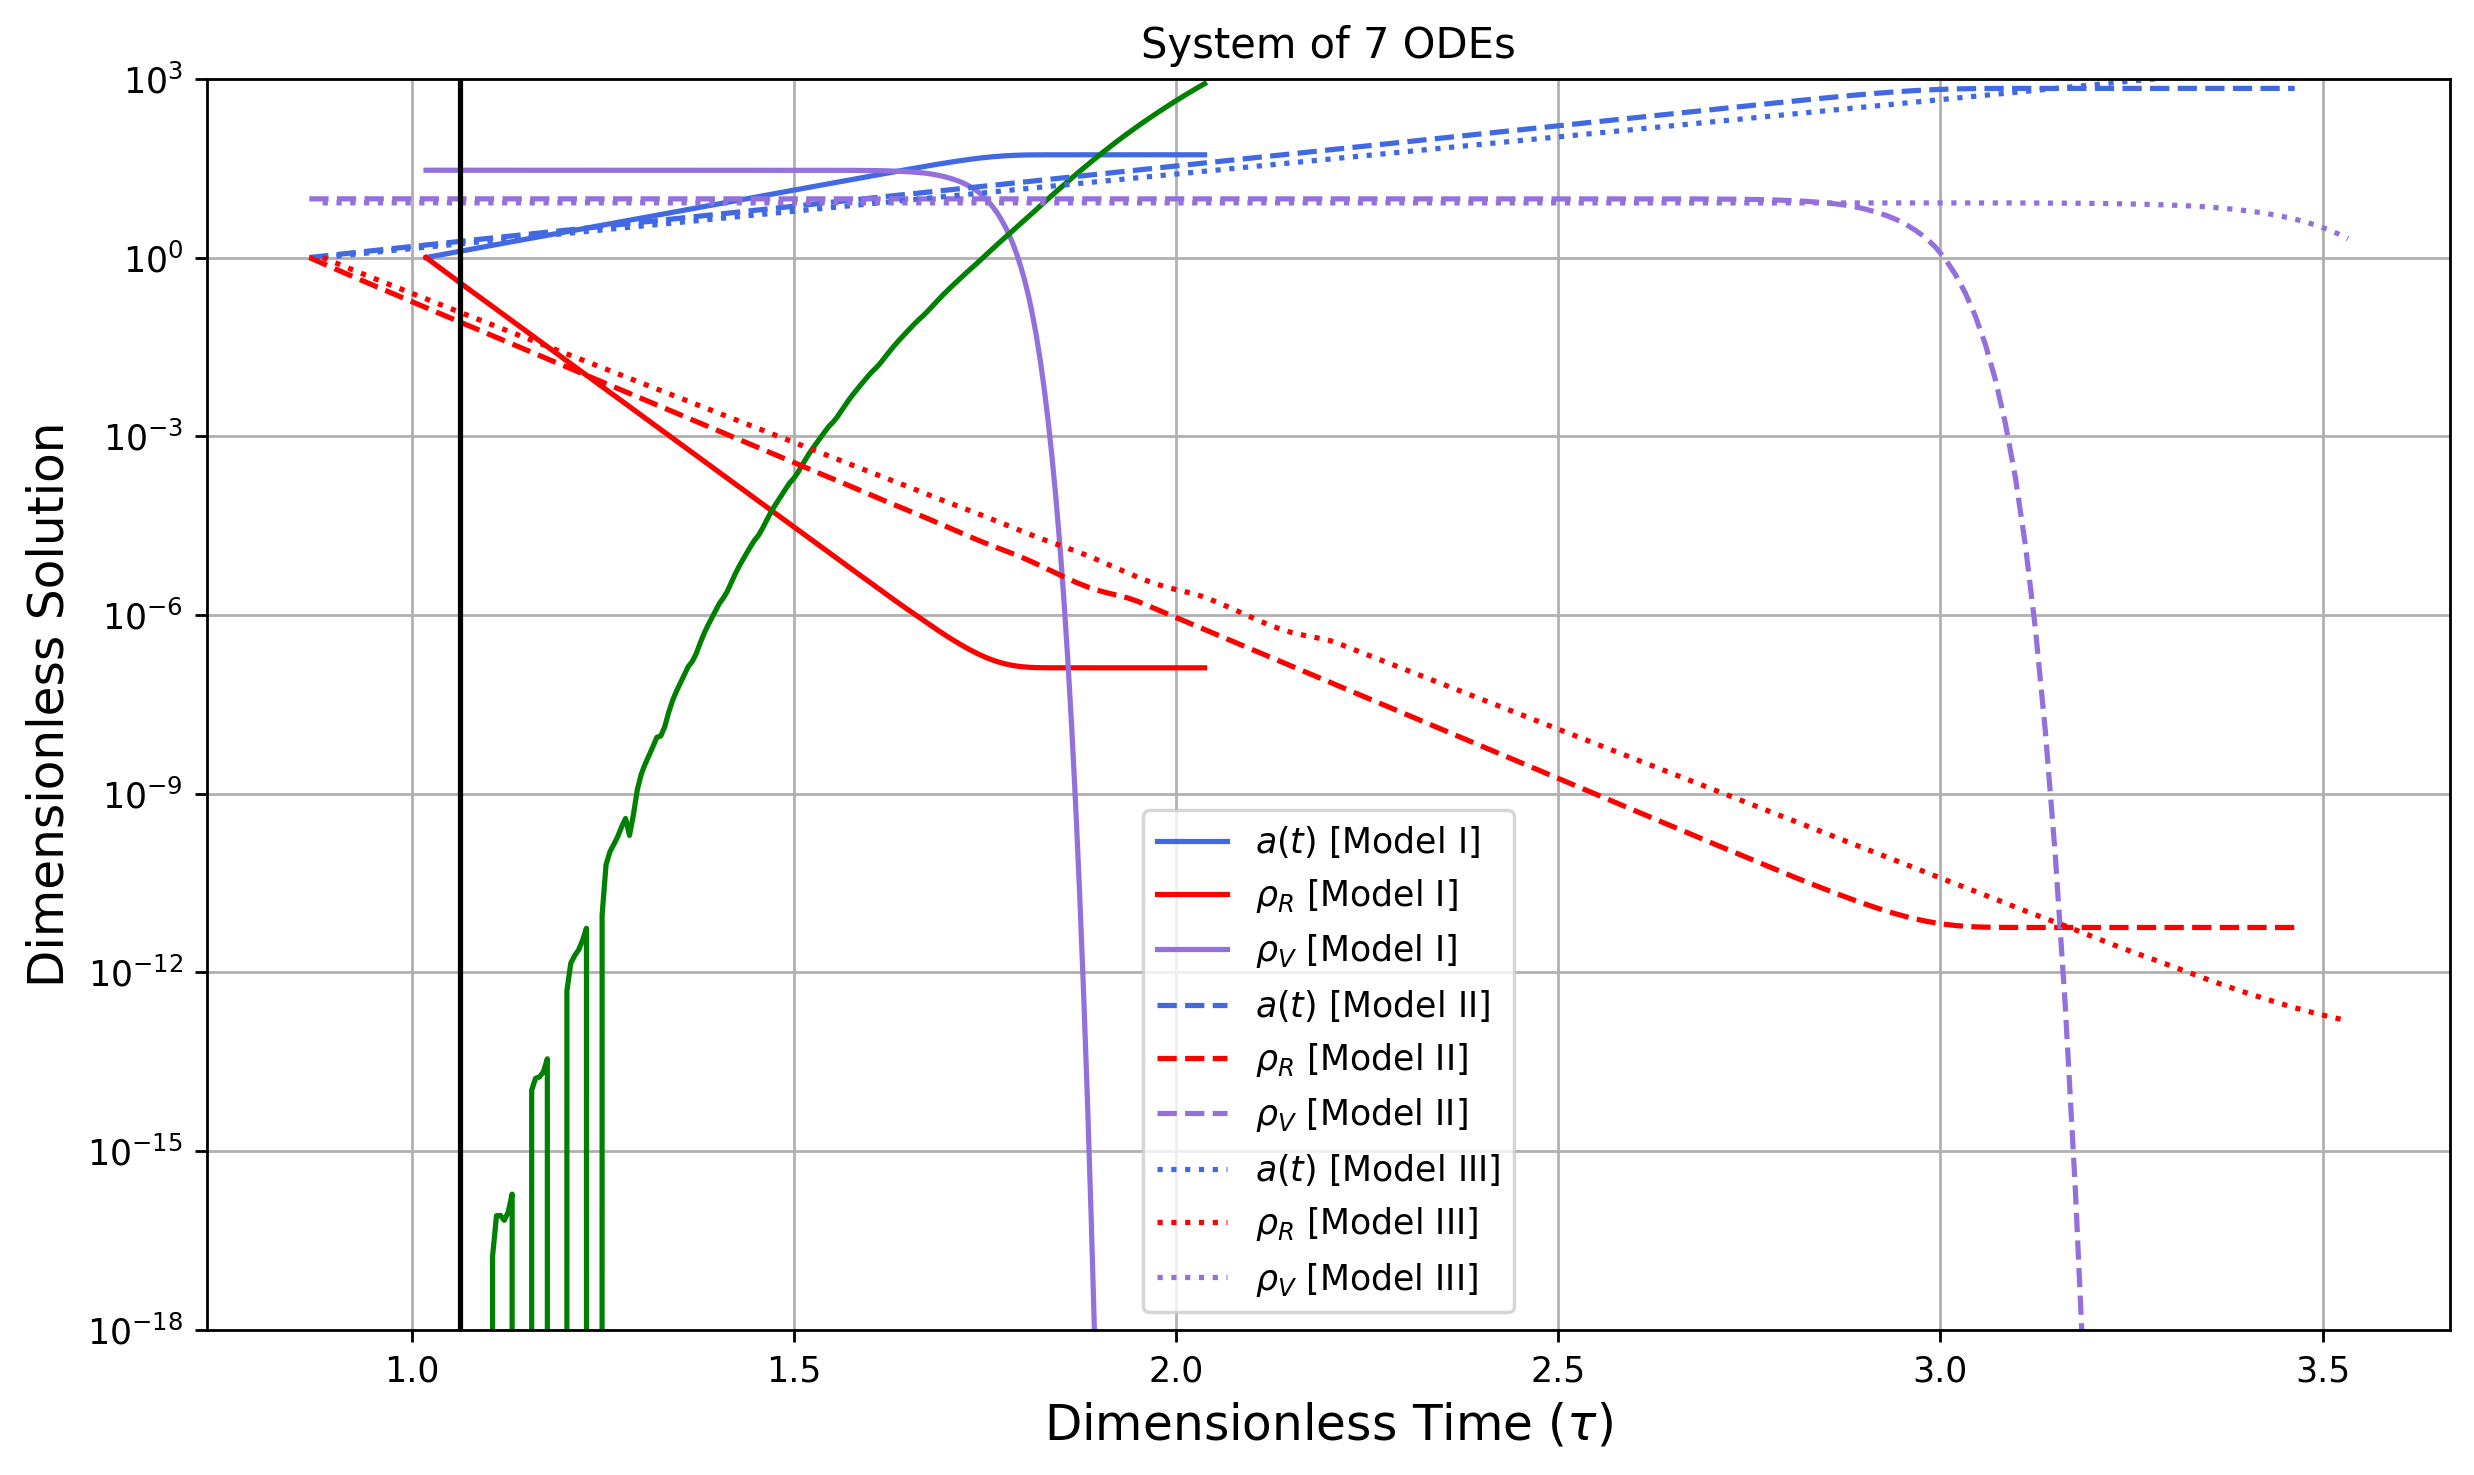

In [ ]:

print(len(res.y))

labels = [r"$a(t)$", r"$\rho_R(t)$", r"$v_0$", r"$v_1$", r"$v_2$", r"$v_3$", r"$r(t)$"]

rhoV = chistory.rhoV(res.t, res.y)
rhoV2 = chistory2.rhoV(res2.t, res2.y)
rhoV3 = chistory3.rhoV(res3.t, res3.y)

I = chistory.I_frac(res.t, res.y[6], res.y[2], res.y[3], res.y[4], res.y[5])

# Plot the results
plt.figure(figsize=(10, 6), dpi=250)

plt.plot(res.t, res.y[0], label=r"$a(t)$ [Model I]", color='royalblue')
plt.plot(res.t, res.y[1], label=r"$\rho_R$ [Model I]", color='r')
plt.plot(res.t, rhoV, label=r"$\rho_V$ [Model I]", color='mediumpurple')
plt.plot(res.t, I, color='green')

plt.plot(res2.t, res2.y[0], label=r"$a(t)$ [Model II]",color='royalblue', ls='dashed')
plt.plot(res2.t, res2.y[1], label=r"$\rho_R$ [Model II]",color='r', ls='dashed')
plt.plot(res2.t, rhoV2, label=r"$\rho_V$ [Model II]", color='mediumpurple', ls='dashed')

plt.plot(res3.t, res3.y[0], label=r"$a(t)$ [Model III]", color='royalblue', ls='dotted')
plt.plot(res3.t, res3.y[1],label=r"$\rho_R$ [Model III]", color='r', ls='dotted')
plt.plot(res3.t, rhoV3, label=r"$\rho_V$ [Model III]", color='mediumpurple', ls='dotted')

# compare with t^1/2 scale factor
#plt.plot(res.t, power(res.t/res.t[0], 1.0), color='k')
#plt.plot(res2.t, power(res2.t/res2.t[0], 1.0), color='k')
#plt.plot(res3.t, power(res3.t/res3.t[0], 1.5), color='k')

plt.xlabel(r'Dimensionless Time ($\tau$)', fontsize=14)
plt.ylabel('Dimensionless Solution', fontsize=14)
plt.title('System of 7 ODEs')
plt.yscale('log')
plt.ylim((1e-18, 1e3))
plt.legend()
plt.grid()
plt.tight_layout()
plt.axvline(chistory.teq * sqrt(chistory.Heq2 / 2), color='black')
plt.show()

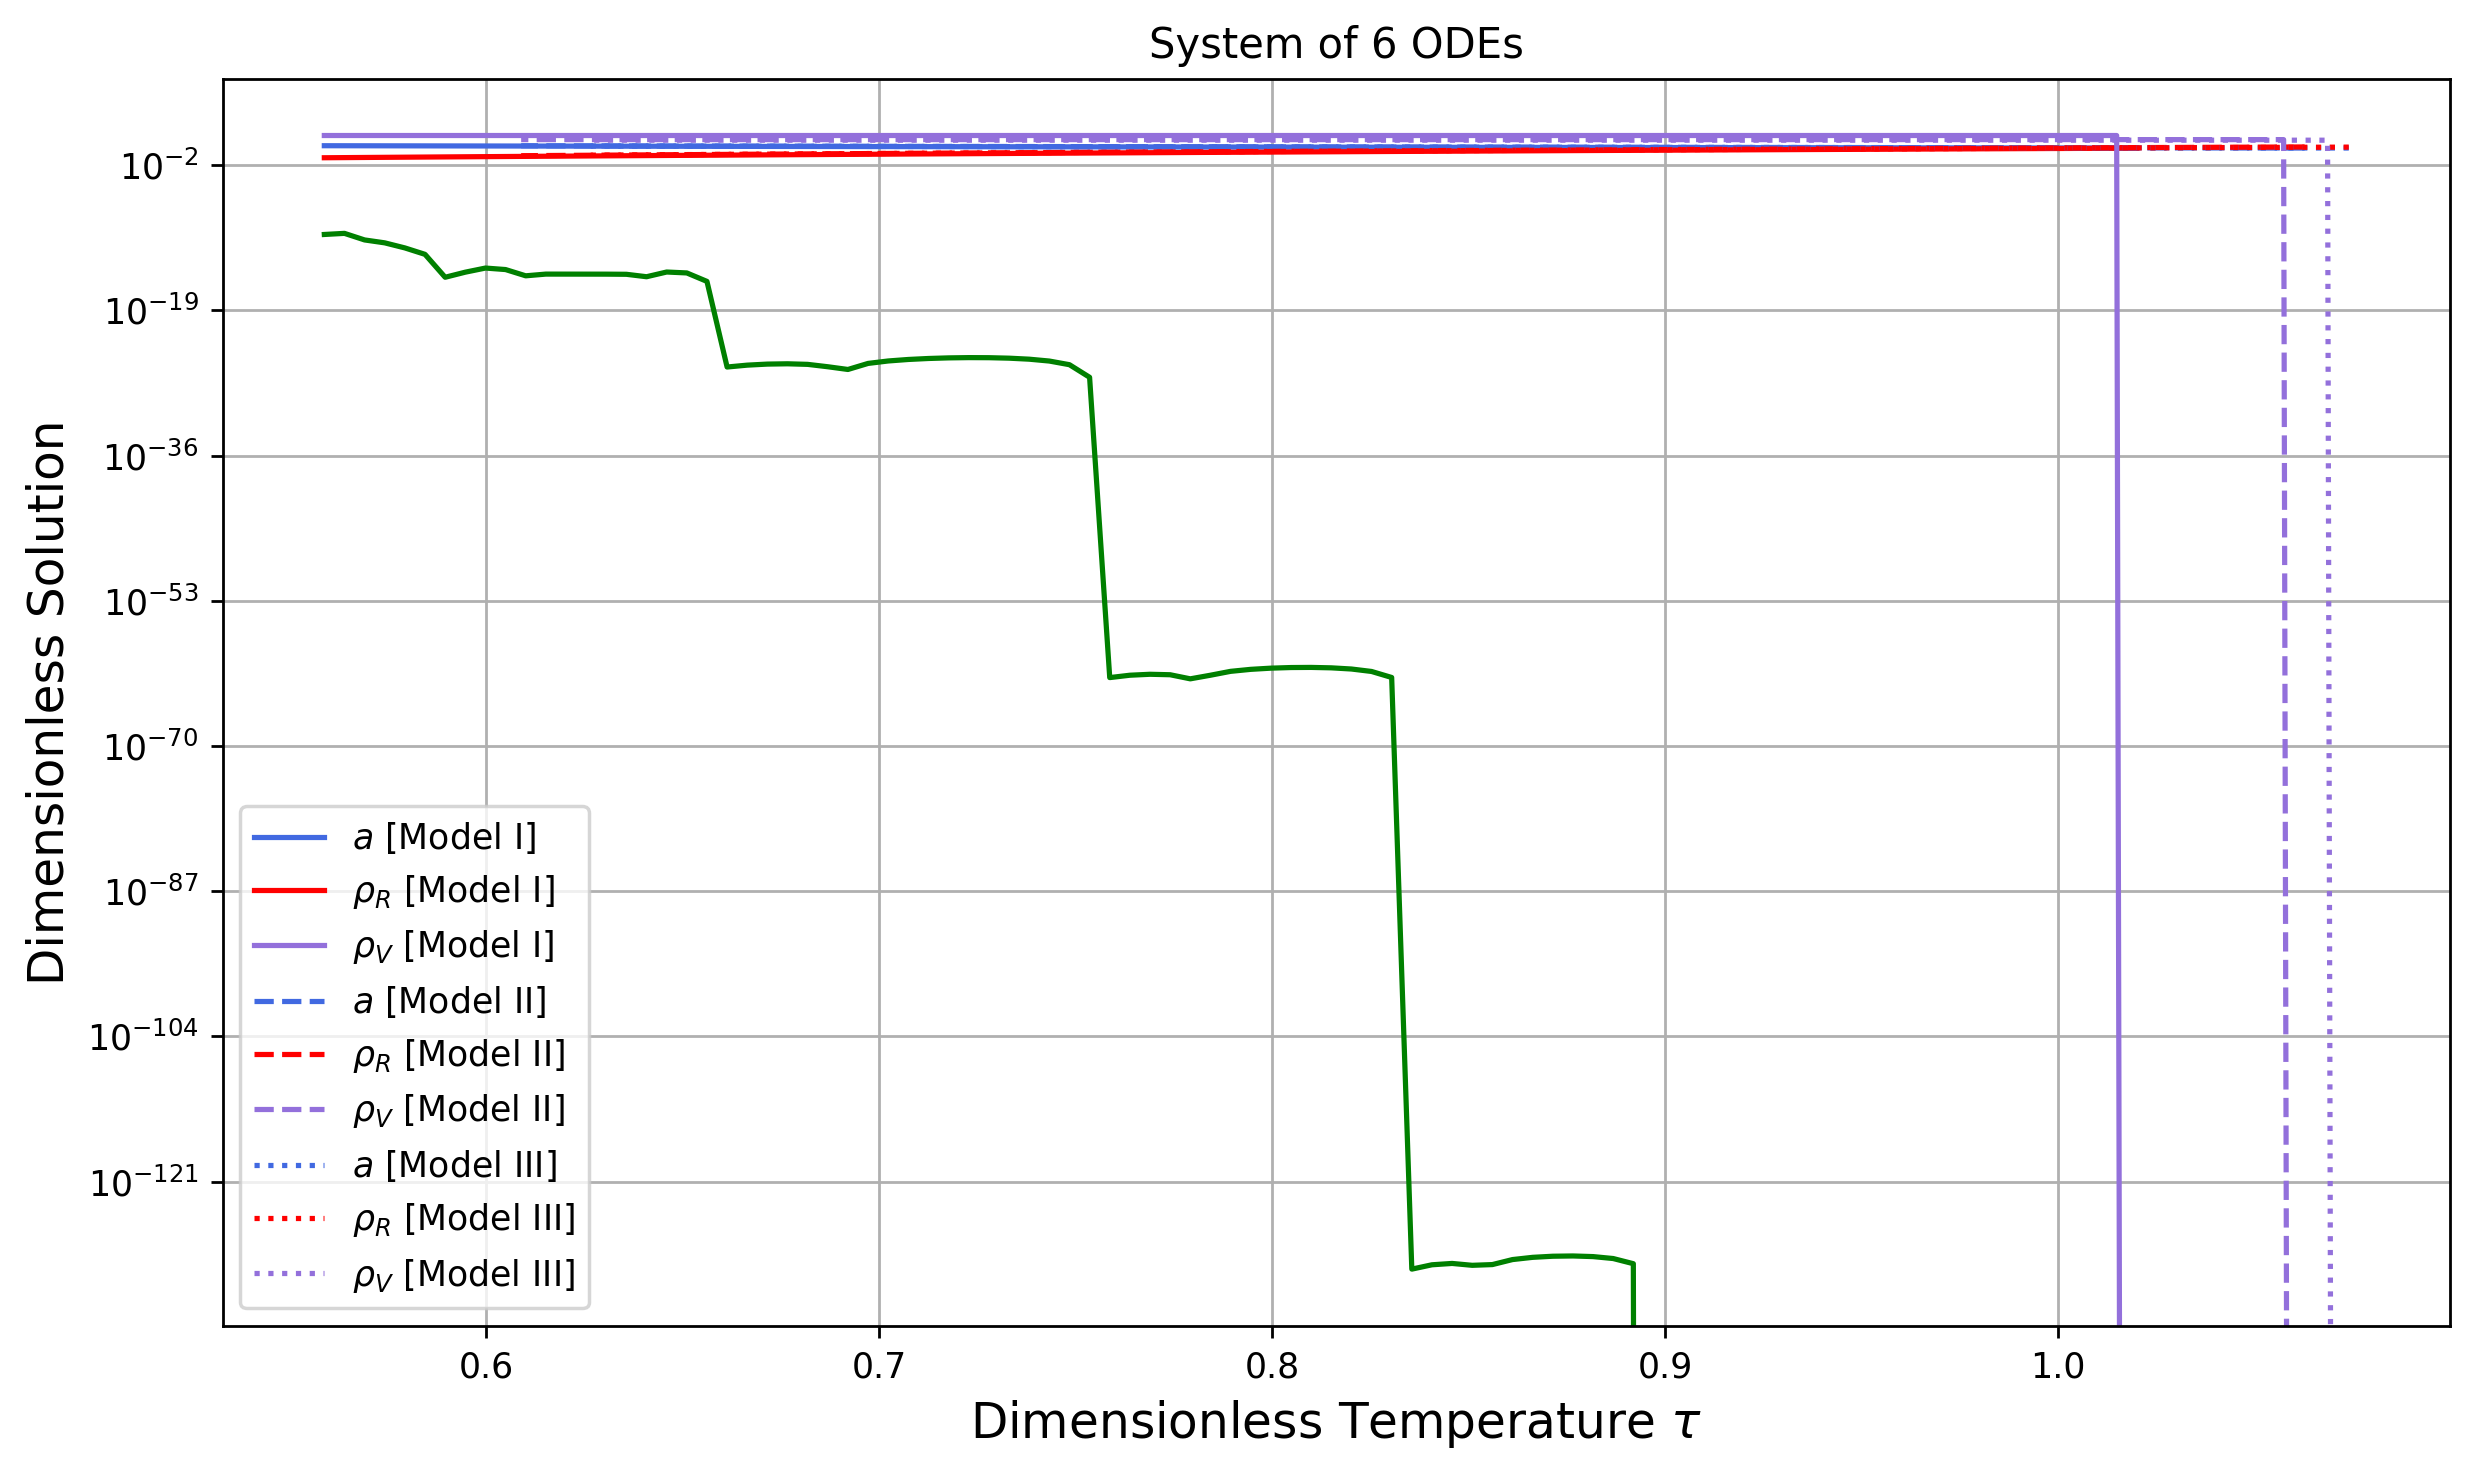

In [ ]:
rhoV = chistory_.rhoV(res_.t, res_.y)
rhoV2 = chistory2_.rhoV(res2_.t, res2_.y)
rhoV3 = chistory3_.rhoV(res3_.t, res3_.y)

rhoR = chistory_.rhoR(res_.t)
rhoR2 = chistory2_.rhoR(res2_.t)
rhoR3 = chistory3_.rhoR(res3_.t)

I = chistory_.I_frac(res_.y[5], res_.y[1], res_.y[2], res_.y[3], res_.y[4])

# Plot the results
plt.figure(figsize=(10, 6), dpi=250)

plt.plot(res_.t, res_.y[0], label=r"$a$ [Model I]", color='royalblue')
plt.plot(res_.t, rhoR, label=r"$\rho_R$ [Model I]", color='r')
plt.plot(res_.t, rhoV, label=r"$\rho_V$ [Model I]", color='mediumpurple')
plt.plot(res_.t, abs(I), color='green')
# plt.plot(res_.t, abs(res_.y[1]), color='green')

plt.plot(res2_.t, res2_.y[0], label=r"$a$ [Model II]",color='royalblue', ls='dashed')
plt.plot(res2_.t, rhoR2, label=r"$\rho_R$ [Model II]",color='r', ls='dashed')
plt.plot(res2_.t, rhoV2, label=r"$\rho_V$ [Model II]", color='mediumpurple', ls='dashed')
# plt.plot(res2_.t, abs(res2_.y[1]), color='green', ls='dashed')

plt.plot(res3_.t, res3_.y[0], label=r"$a$ [Model III]", color='royalblue', ls='dotted')
plt.plot(res3_.t, rhoR3, label=r"$\rho_R$ [Model III]", color='r', ls='dotted')
plt.plot(res3_.t, rhoV3, label=r"$\rho_V$ [Model III]", color='mediumpurple', ls='dotted')
# plt.plot(res3_.t, abs(res3_.y[1]), color='green', ls='dotted')

# compare with t^1/2 scale factor
# plt.plot(res_.t, power(res_.t/res_.t[0], 0.5), color='k')
# plt.plot(res2_.t, power(res2_.t/res2_.t[0], 0.5), color='k')
# plt.plot(res3_.t, power(res3_.t/res3_.t[0], 0.5), color='k')

plt.xlabel(r'Dimensionless Temperature $\tau$', fontsize=14)
plt.ylabel('Dimensionless Solution', fontsize=14)
plt.title('System of 6 ODEs')
# plt.xscale('log')
plt.yscale('log')
# plt.ylim((1e-3, 1e2))
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [22]:
res_.t

array([1.02009432, 1.01496822, 1.00984212, 1.00471601, 0.99958991,
       0.99446381, 0.98933771, 0.98421161, 0.9790855 , 0.9739594 ,
       0.9688333 , 0.9637072 , 0.9585811 , 0.95345499, 0.94832889,
       0.94320279, 0.93807669, 0.93295059, 0.92782448, 0.92269838,
       0.91757228, 0.91244618, 0.90732007, 0.90219397, 0.89706787,
       0.89194177, 0.88681567, 0.88168956, 0.87656346, 0.87143736,
       0.86631126, 0.86118516, 0.85605905, 0.85093295, 0.84580685,
       0.84068075, 0.83555465, 0.83042854, 0.82530244, 0.82017634,
       0.81505024, 0.80992414, 0.80479803, 0.79967193, 0.79454583,
       0.78941973, 0.78429363, 0.77916752, 0.77404142, 0.76891532,
       0.76378922, 0.75866312, 0.75353701, 0.74841091, 0.74328481,
       0.73815871, 0.7330326 , 0.7279065 , 0.7227804 , 0.7176543 ,
       0.7125282 , 0.70740209, 0.70227599, 0.69714989, 0.69202379,
       0.68689769, 0.68177158, 0.67664548, 0.67151938, 0.66639328,
       0.66126718, 0.65614107, 0.65101497, 0.64588887, 0.64076

# Universe with only radiation

This section uses ```rhoV(self, tau, y)``` = 0 = ```drhoV_dtau(self, tau, y)``` and $g_{\rm rad} (T) = g_{\rm rad} (T_c)$.

## Hubble parameter

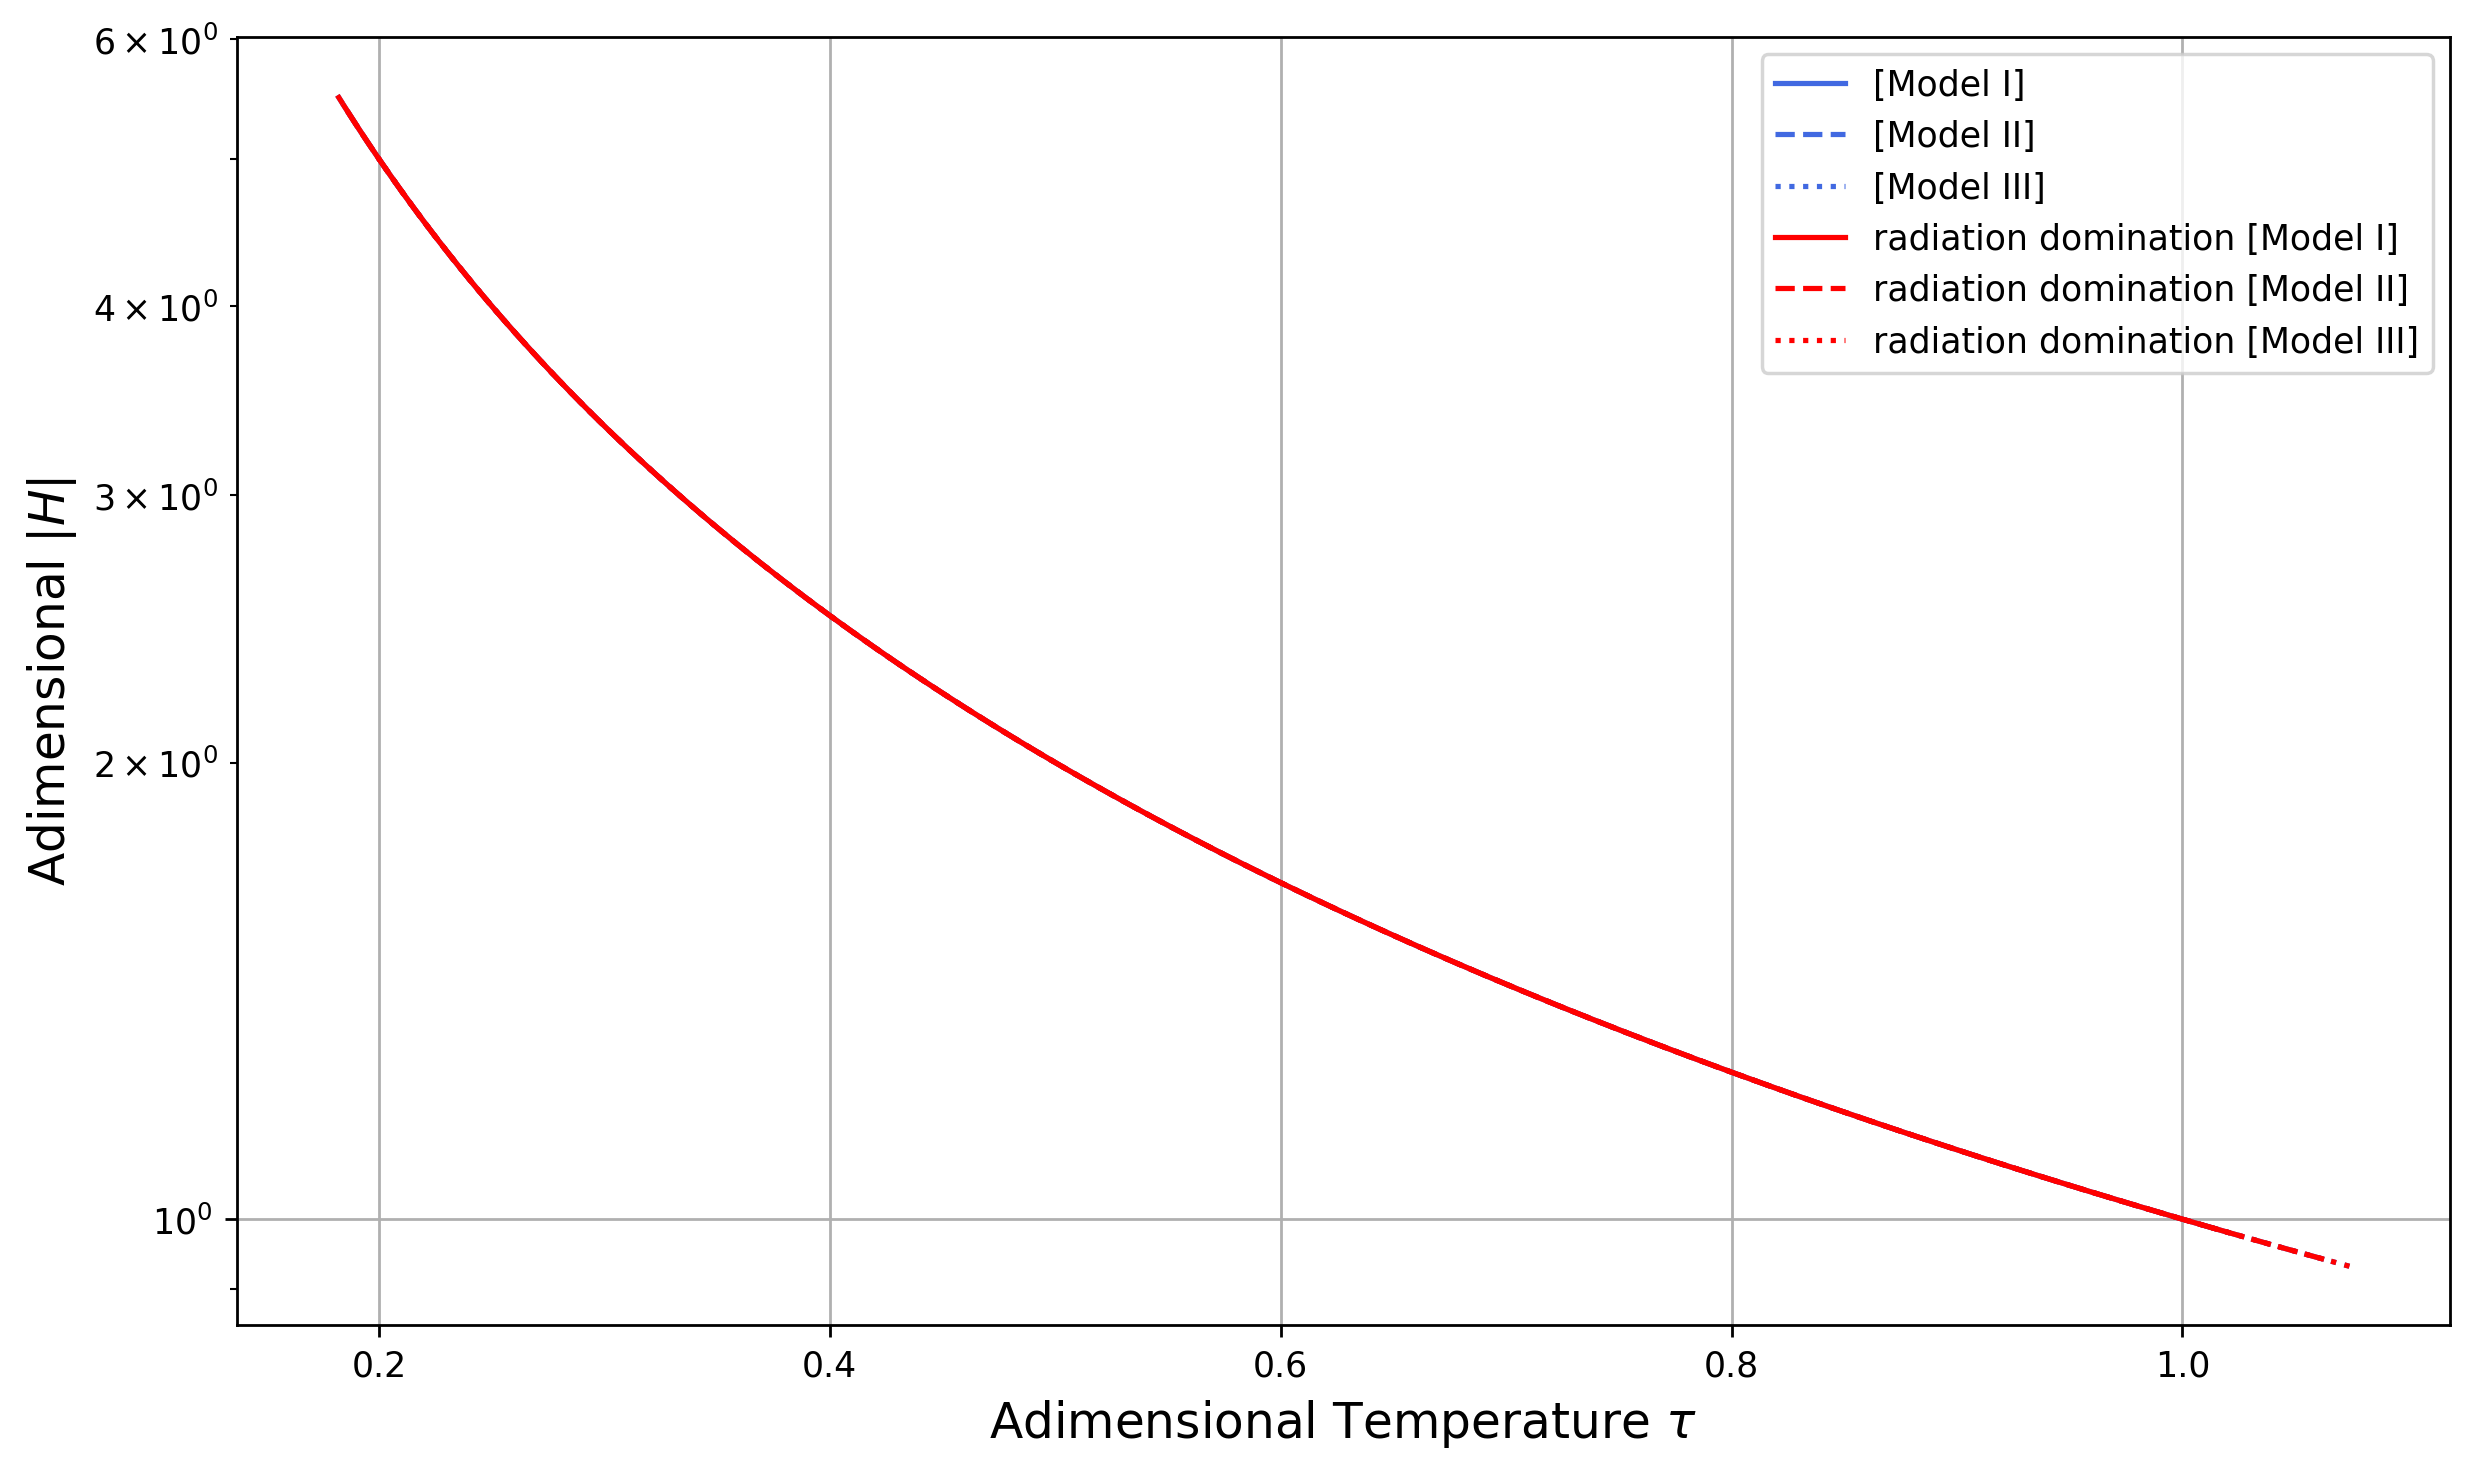

In [8]:
H1 = chistory_.da_dtau(res_.t, res_.y, dT_dt=chistory_.dT_dt(res_.t, res_.y)) / res_.y[0]
H2 = chistory2_.da_dtau(res2_.t, res2_.y, dT_dt=chistory2_.dT_dt(res2_.t, res2_.y)) / res2_.y[0]
H3 = chistory3_.da_dtau(res3_.t, res3_.y, dT_dt=chistory3_.dT_dt(res3_.t, res3_.y)) / res3_.y[0]


# plots
plt.figure(figsize=(10, 6), dpi=250)

plt.plot(res_.t, abs(H1), label=r"[Model I]", color='royalblue')
plt.plot(res2_.t, abs(H2), label=r"[Model II]",color='royalblue', ls='dashed')
plt.plot(res3_.t, abs(H3), label=r"[Model III]", color='royalblue', ls='dotted')
# plt.axvline(0.1*chistory_.tau_crit)

# compare with radiation domination
dT_dt_dim = chistory_.dT_dt(res_.t, res_.y) / sqrt(chistory_.c) / chistory_.temperature_to_tau(1)
dT_dt_dim2 = chistory2_.dT_dt(res2_.t, res2_.y) / sqrt(chistory2_.c) / chistory2_.temperature_to_tau(1)
dT_dt_dim3 = chistory3_.dT_dt(res3_.t, res3_.y) / sqrt(chistory3_.c) / chistory3_.temperature_to_tau(1)

# Hubble parameter that aligns with approximations within code
def H_R(T, Tc):
    # Tc = T
    return sqrt(pi**2 / 90 / M_pl**2 * gstar_sm(Tc) * T**4)

H_rad1 = H_R(chistory_.tau_to_temperature(res_.t), chistory_.Tc) / dT_dt_dim / chistory_.temperature_to_tau(1)
H_rad2 = H_R(chistory2_.tau_to_temperature(res2_.t), chistory2_.Tc) / dT_dt_dim2 / chistory2_.temperature_to_tau(1)
H_rad3 = H_R(chistory3_.tau_to_temperature(res3_.t), chistory3_.Tc) / dT_dt_dim3 / chistory3_.temperature_to_tau(1)

plt.plot(res_.t, abs(H_rad1), label="radiation domination [Model I]", color='red')
plt.plot(res2_.t, abs(H_rad2), label="radiation domination [Model II]", color='red', ls='dashed')
plt.plot(res3_.t, abs(H_rad3), label="radiation domination [Model III]", color='red', ls='dotted')

plt.xlabel(r'Adimensional Temperature $\tau$', fontsize=14)
plt.ylabel(r'Adimensional $|H|$', fontsize=14)
# plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

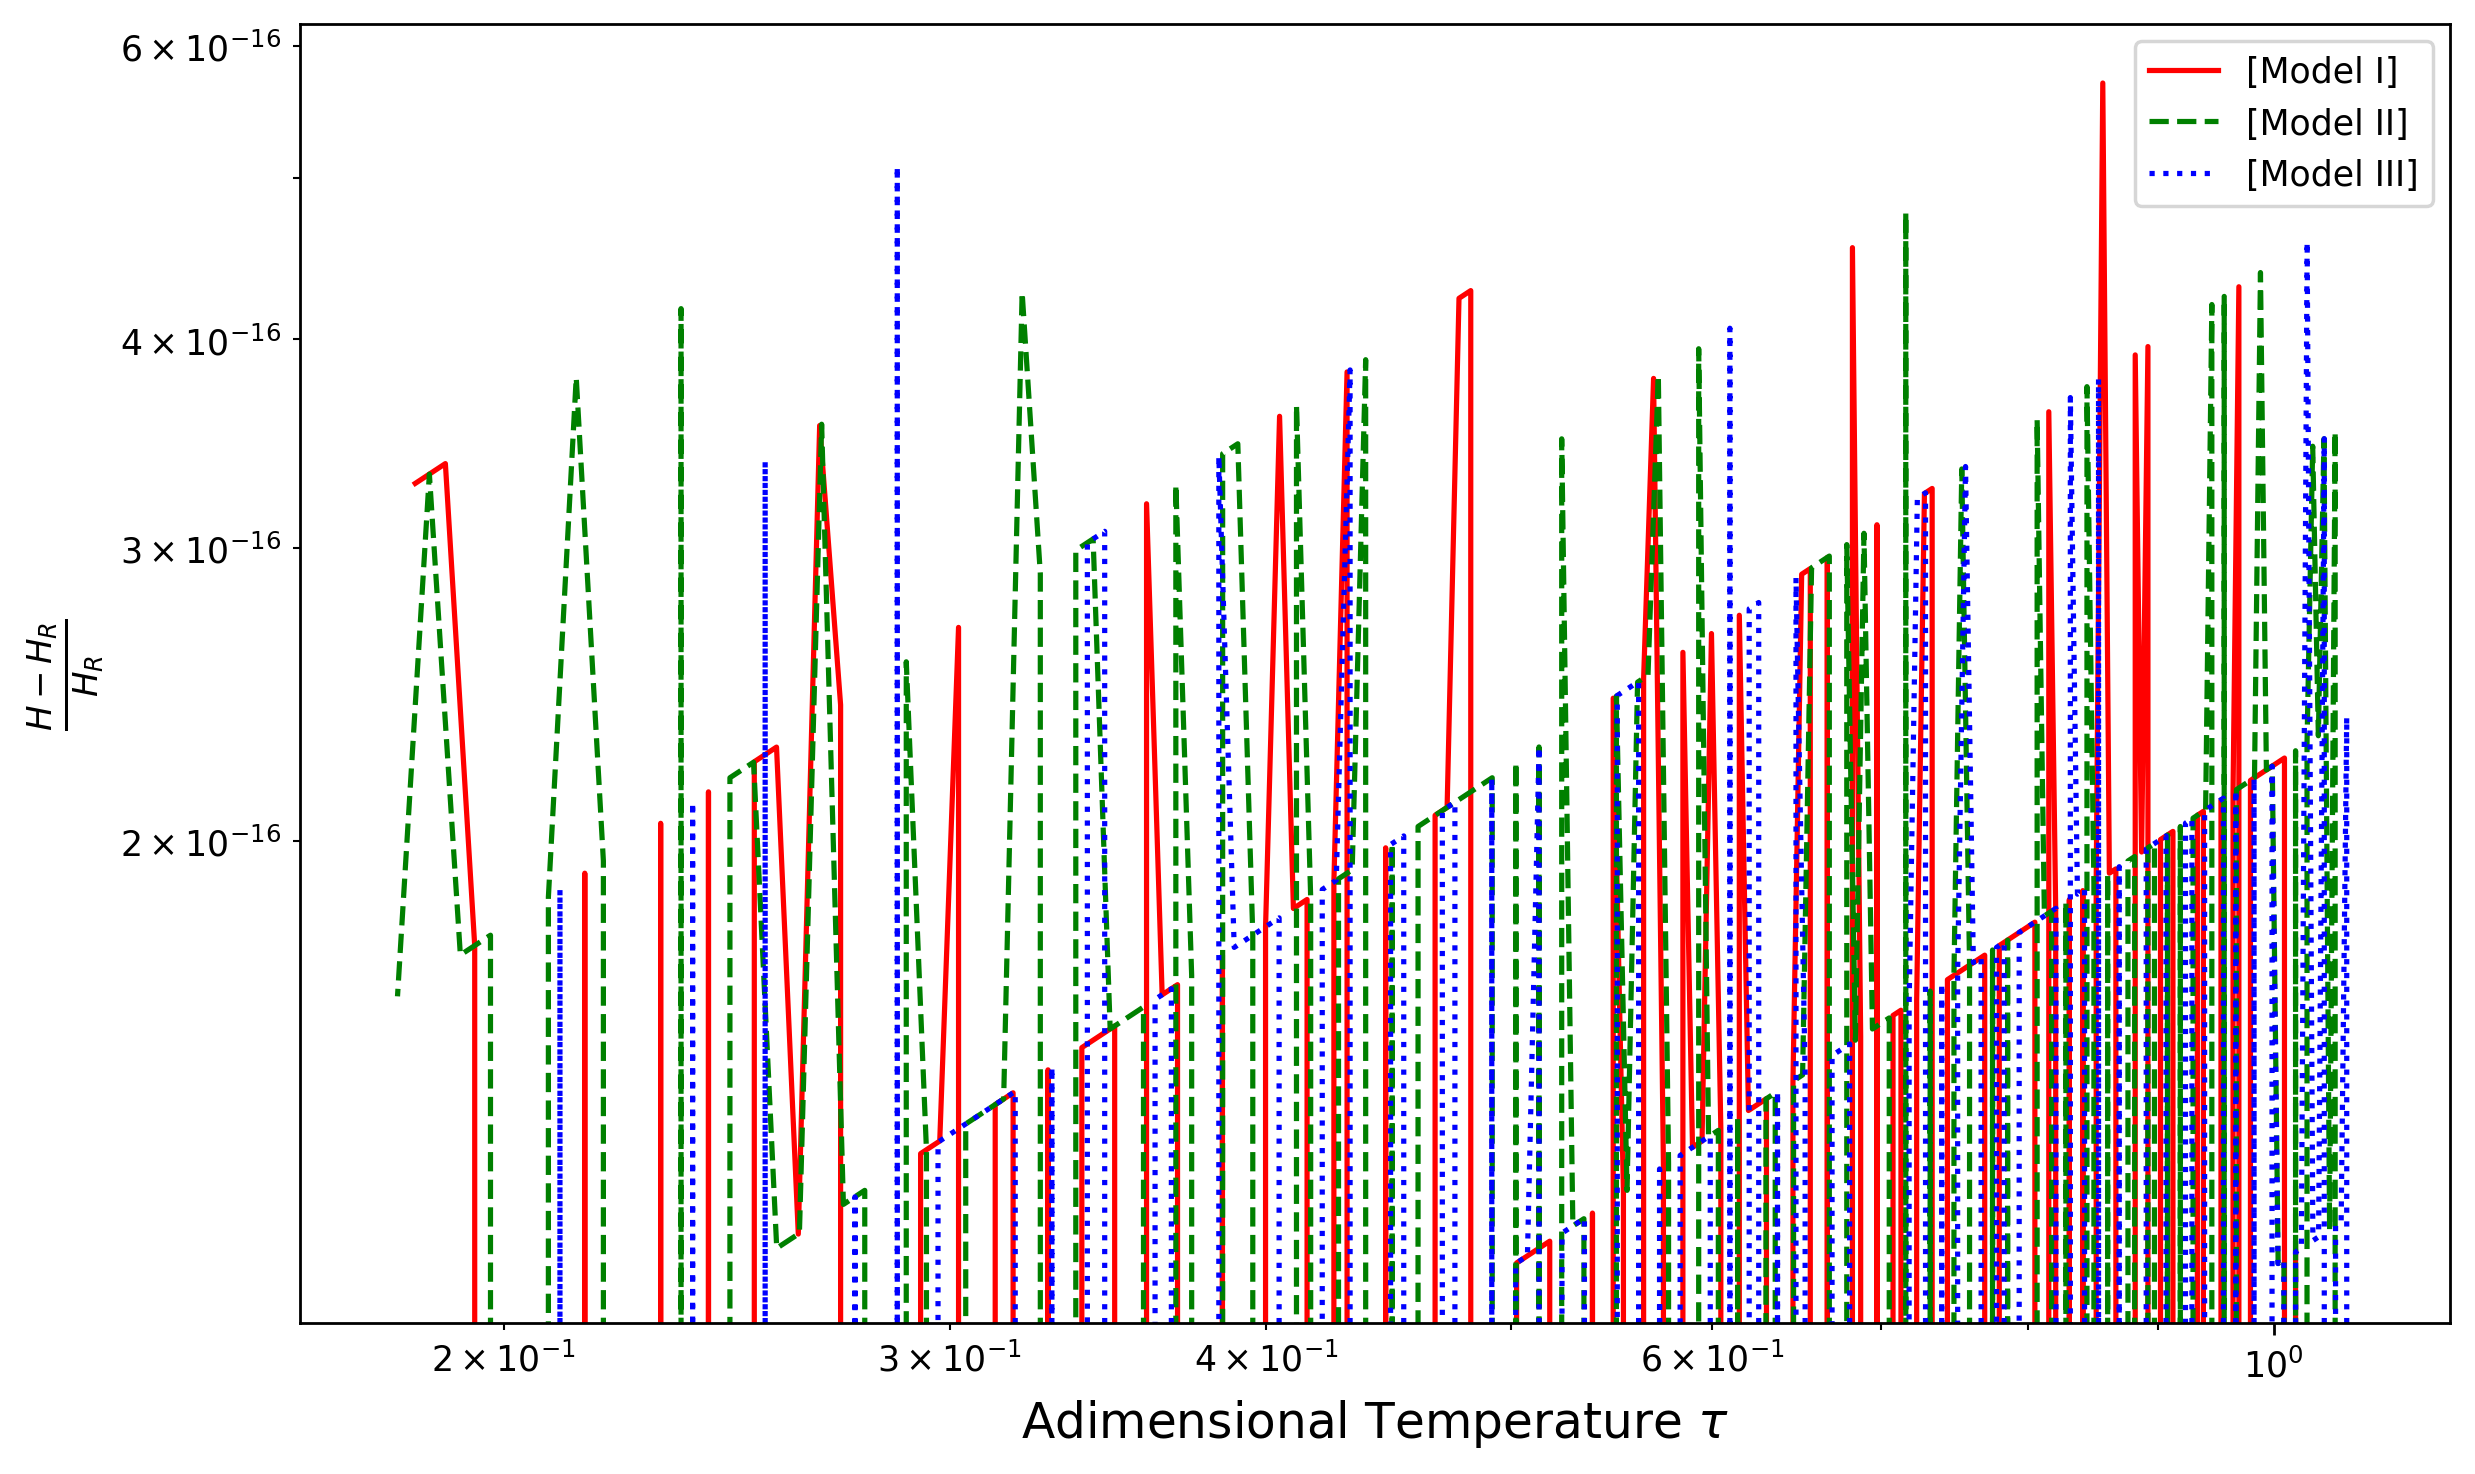

In [9]:
# plot percent errors
error = abs((H1 - H_rad1) / H_rad1)
error2 = abs((H2 - H_rad2) / H_rad2)
error3 = abs((H3 - H_rad3) / H_rad3)

plt.figure(figsize=(10, 6), dpi=250)

plt.plot(res_.t, error, label=r"[Model I]", color='red')
plt.plot(res2_.t, error2, label=r"[Model II]",color='green', ls='dashed')
plt.plot(res3_.t, error3, label=r"[Model III]", color='blue', ls='dotted')

plt.xlabel(r'Adimensional Temperature $\tau$', fontsize=14)
plt.ylabel(r'$\frac{H - H_R}{H_R}$', fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

## $\frac{dT}{dt} \approx -HT$

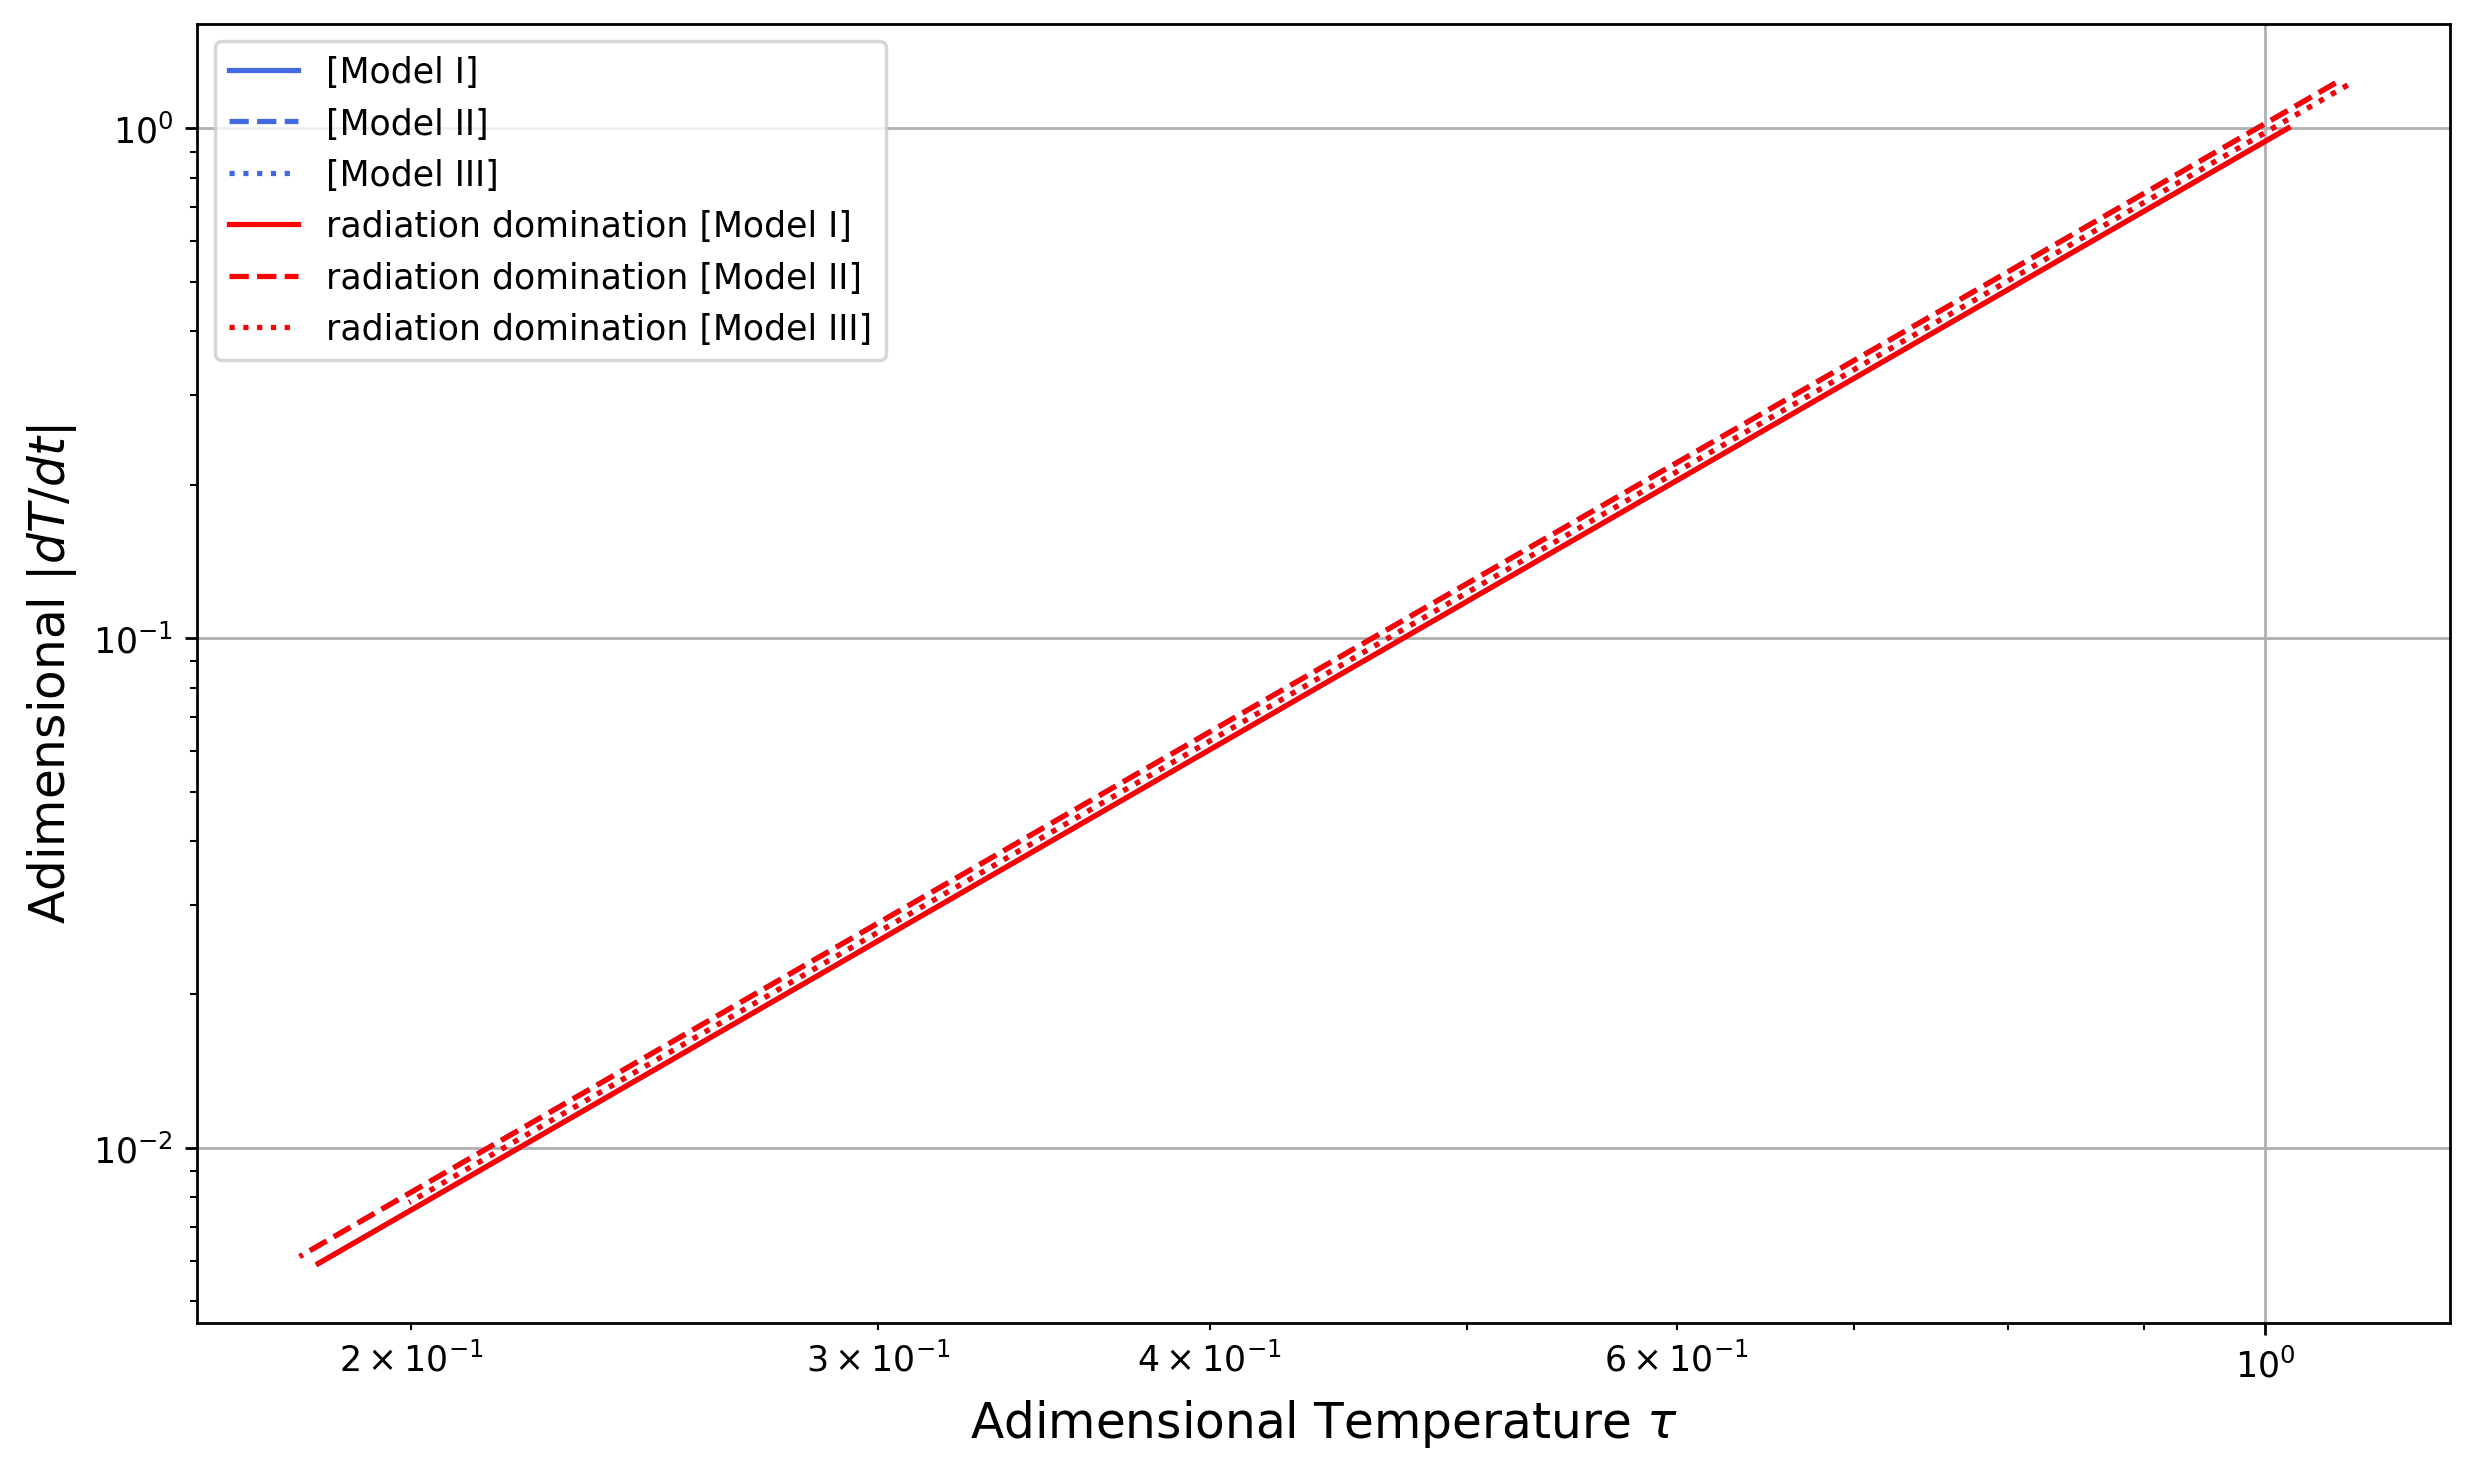

In [10]:
# dT_dt = res_.y[6]
# dT_dt2 = res2_.y[6]
# dT_dt3 = res3_.y[6]
dT_dt = chistory_.dT_dt(res_.t, res_.y)
dT_dt2 = chistory2_.dT_dt(res2_.t, res2_.y)
dT_dt3 = chistory3_.dT_dt(res3_.t, res3_.y)


# Plot the results
plt.figure(figsize=(10, 6), dpi=250)

plt.plot(res_.t, abs(dT_dt), label=r"[Model I]", color='royalblue')
plt.plot(res2_.t, abs(dT_dt2), label=r"[Model II]",color='royalblue', ls='dashed')
plt.plot(res3_.t, abs(dT_dt3), label=r"[Model III]", color='royalblue', ls='dotted')
# plt.axvline(0.1*chistory_.tau_crit)

# compare with radiation domination
dT_dt_rad = (-H_R(chistory_.tau_to_temperature(res_.t), chistory_.Tc) * chistory_.tau_to_temperature(res_.t)) * sqrt(chistory_.c) * chistory_.temperature_to_tau(1)
dT_dt_rad2 = (-H_R(chistory2_.tau_to_temperature(res2_.t), chistory2_.Tc) * chistory2_.tau_to_temperature(res2_.t)) * sqrt(chistory2_.c) * chistory2_.temperature_to_tau(1)
dT_dt_rad3 = (-H_R(chistory3_.tau_to_temperature(res3_.t), chistory3_.Tc) * chistory3_.tau_to_temperature(res3_.t)) * sqrt(chistory3_.c) * chistory3_.temperature_to_tau(1)

plt.plot(res_.t, abs(dT_dt_rad), label="radiation domination [Model I]", color='red')
plt.plot(res2_.t, abs(dT_dt_rad2), label="radiation domination [Model II]", color='red', ls='dashed')
plt.plot(res3_.t, abs(dT_dt_rad3), label="radiation domination [Model III]", color='red', ls='dotted')

plt.xlabel(r'Adimensional Temperature $\tau$', fontsize=14)
plt.ylabel(r'Adimensional $|dT/dt|$', fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [11]:
slope, intercept = np.polyfit(np.log10(res_.t), np.log10(-dT_dt), 1)
slope_R, intercept_R = np.polyfit(np.log10(res_.t), np.log10(-dT_dt_rad), 1)

print('data:', slope, intercept)
print('radiation-domination:', slope_R, intercept_R)

data: 2.999999999999998 -0.02530324080532908
radiation-domination: 2.999999999999998 -0.02530324080532908


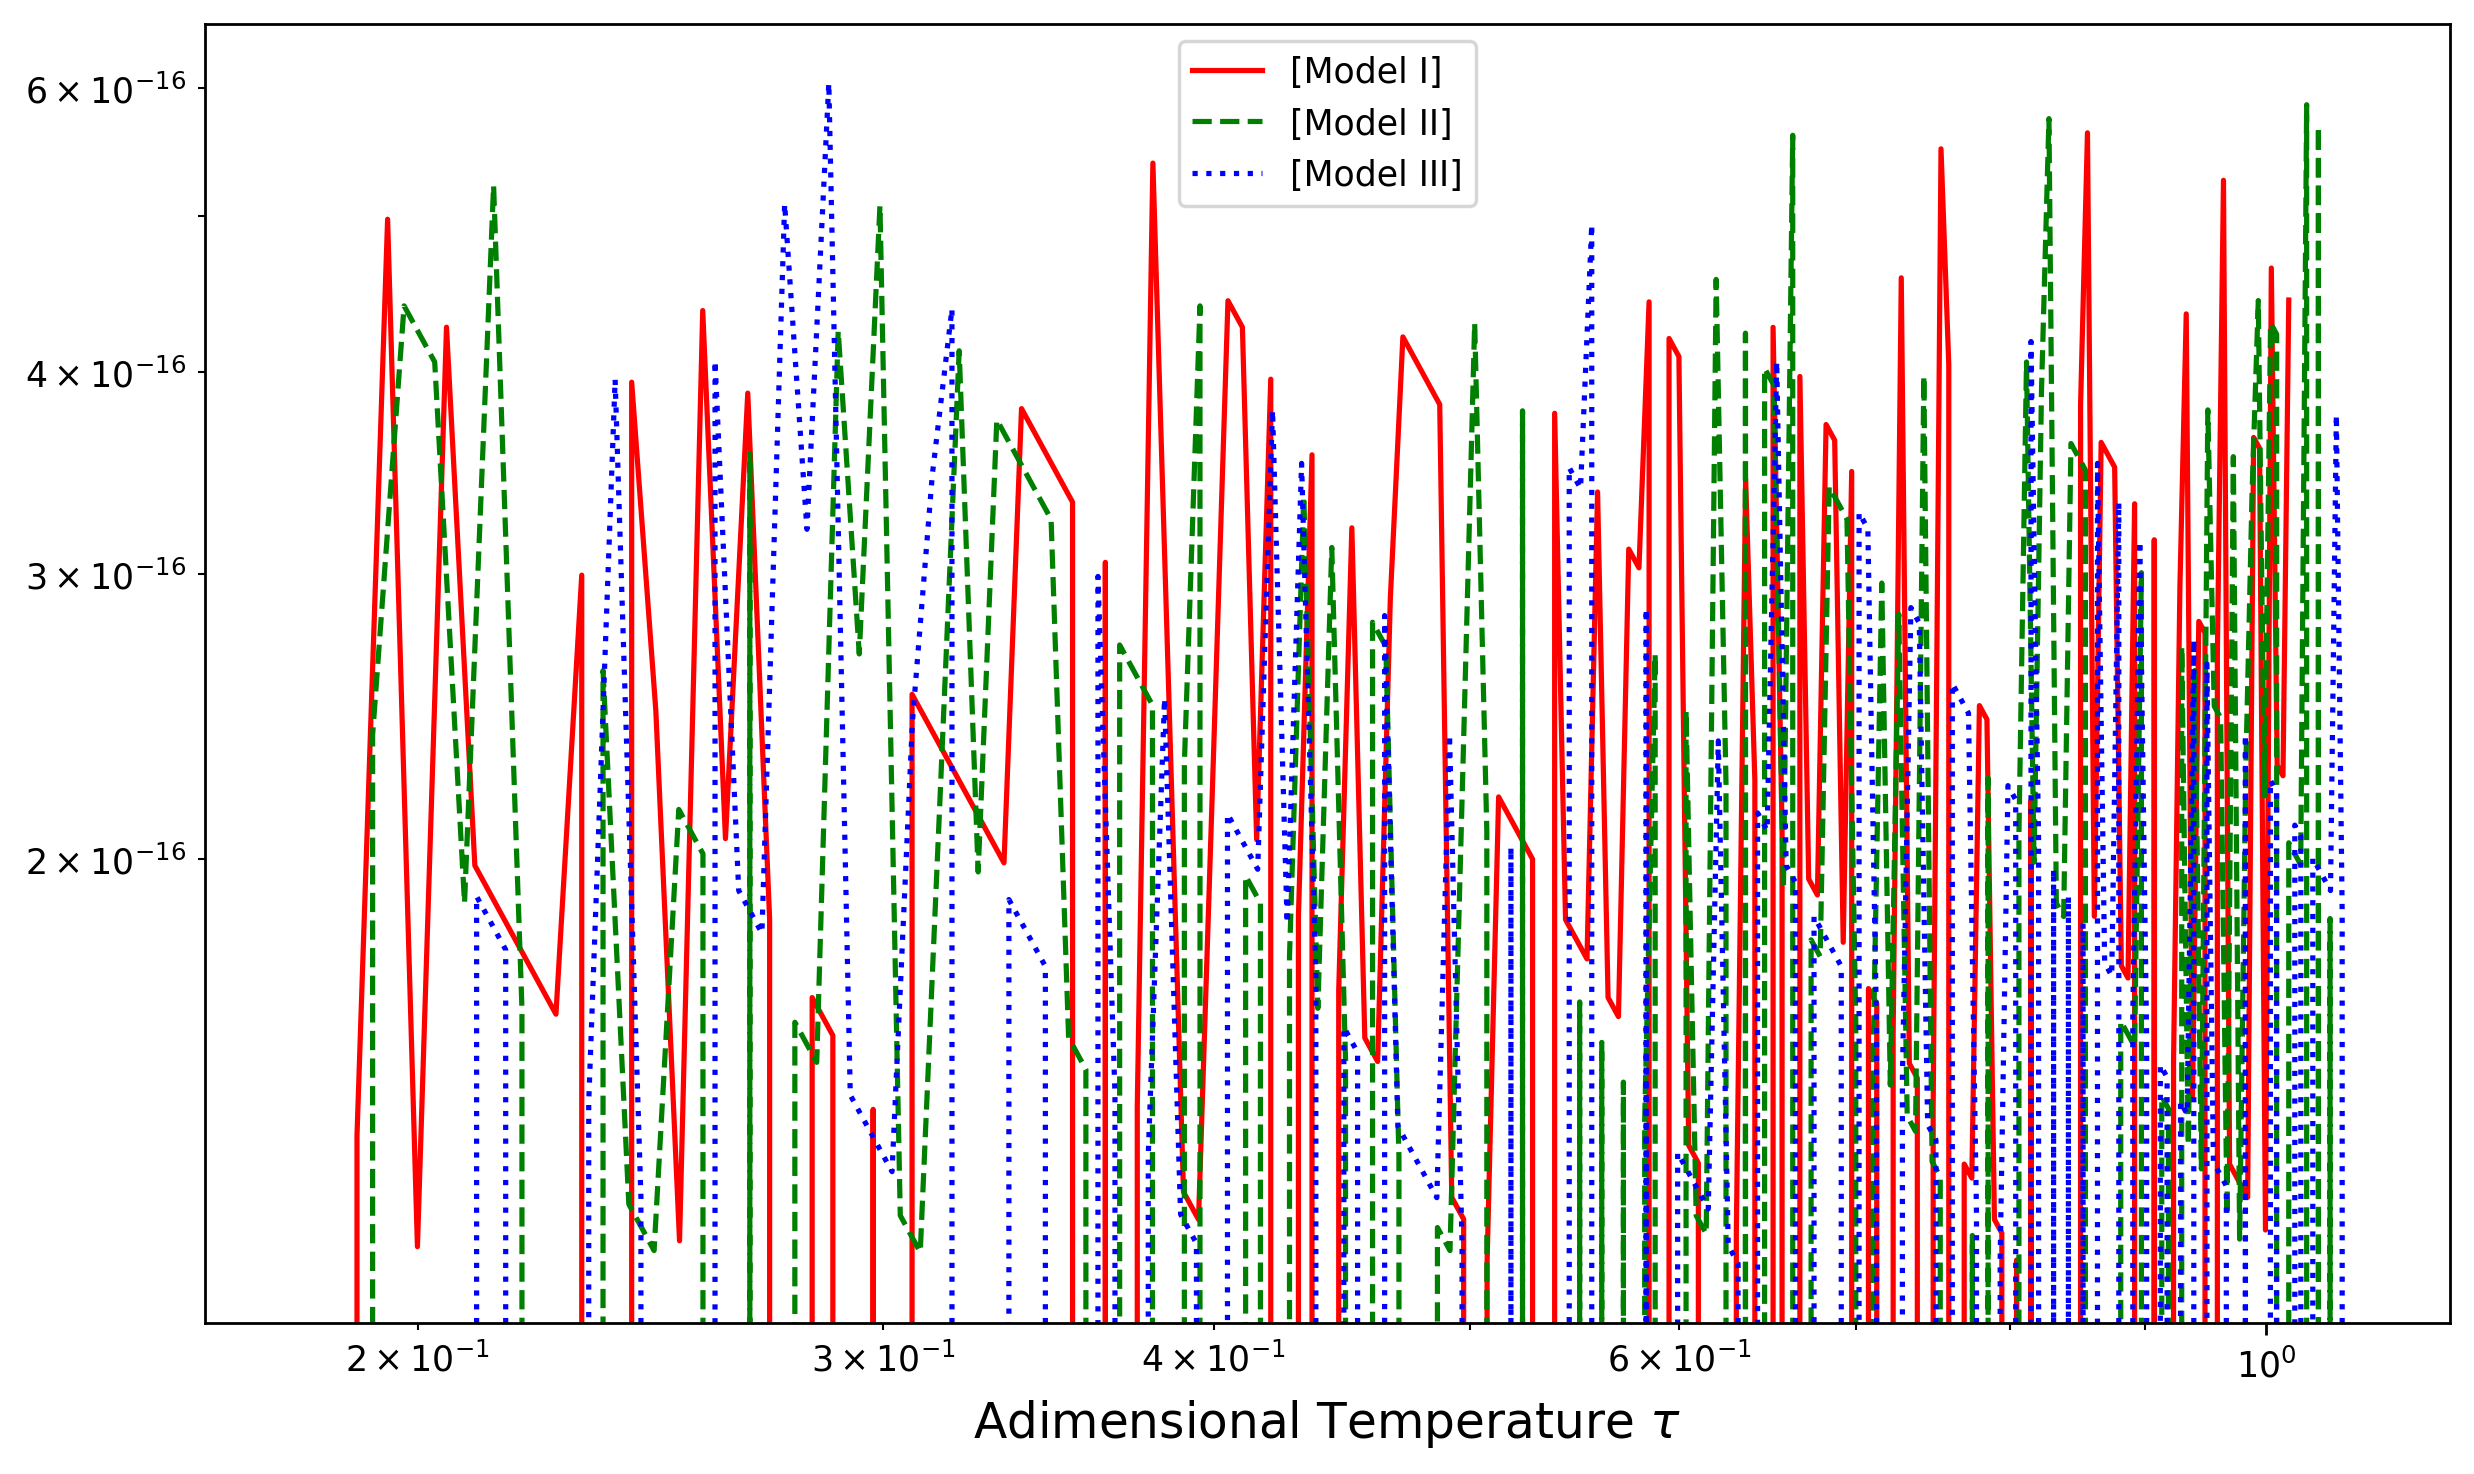

In [12]:
# plot percent errors
error = abs((dT_dt - dT_dt_rad) / dT_dt_rad)
error2 = abs((dT_dt2 - dT_dt_rad2) / dT_dt_rad2)
error3 = abs((dT_dt3 - dT_dt_rad3) / dT_dt_rad3)

plt.figure(figsize=(10, 6), dpi=250)

plt.plot(res_.t, error, label=r"[Model I]", color='red')
plt.plot(res2_.t, error2, label=r"[Model II]",color='green', ls='dashed')
plt.plot(res3_.t, error3, label=r"[Model III]", color='blue', ls='dotted')

plt.xlabel(r'Adimensional Temperature $\tau$', fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

# $B-L$ effective potentials and ```cosmoTransitions```

In [1]:
import sys
sys.path.append("../")

import matplotlib.pyplot as plt
from pypt.vac_rad_cosmic_history_dT_dt import *

point = {'alpha_BL0': 0.023497140279514744,
 'alpha_Y0': 0.02015477445789964,
 'mu': 1.0,
 'phi_crit': 0.9459435998693794,
 'T_crit': 0.30730750774272353,
 'T_PT': 0.14783802583501146,
 'alpha': 0.7432306123434936,
 'beta_over_H': 295.0578105789055}

Veff = VeffBL(point['alpha_BL0'], point['alpha_Y0'], point['mu'])
CHistory = CosmicHistoryVacuumRadiation_dT_dt(Veff, vw=1)

/Users/casheh/Library/CloudStorage/OneDrive-UniversityofNebraska-Lincoln/Research/PTs/PBHs/python/pypt/../pypt/ftpot.py:670: RuntimeWarning: divide by zero encountered in divide
  return sum(field.dof * dJ_B(field.mass_squared(phi,T)/T**2 + field.Debye_mass_squared(phi,T)/T**2) * (field.dmass_squared(phi, T) + field.dDebye_mass_squared(phi, T)) \
/Users/casheh/Library/CloudStorage/OneDrive-UniversityofNebraska-Lincoln/Research/PTs/PBHs/python/pypt/../pypt/ftpot.py:670: RuntimeWarning: invalid value encountered in divide
  return sum(field.dof * dJ_B(field.mass_squared(phi,T)/T**2 + field.Debye_mass_squared(phi,T)/T**2) * (field.dmass_squared(phi, T) + field.dDebye_mass_squared(phi, T)) \
/Users/casheh/Library/CloudStorage/OneDrive-UniversityofNebraska-Lincoln/Research/PTs/PBHs/python/pypt/../pypt/ftpot.py:673: RuntimeWarning: divide by zero encountered in divide
  return sum(field.dof * dJ_F(field.mass_squared(phi,T)/T**2) * (field.dmass_squared(phi, T)) \


In [2]:
CHistory.rhoR(1), CHistory.dV(1, CHistory.tau_to_temperature(1)) * CHistory.c/ (3*power(M_pl, 2))

(np.float64(0.9763521026145253), np.float64(0.9999878023524018))

In [3]:
r = point['T_PT']/point["T_crit"]
Res = CHistory.solve_system(tau_min=0.5)

/Users/casheh/Library/CloudStorage/OneDrive-UniversityofNebraska-Lincoln/Research/PTs/PBHs/python/pypt/../cosmoTransitions/tunneling1D.py:416: RuntimeWarning: overflow encountered in scalar multiply
  r *= 10


ValueError: The function value at x=5.621541415203022e+307 is NaN; solver cannot continue.

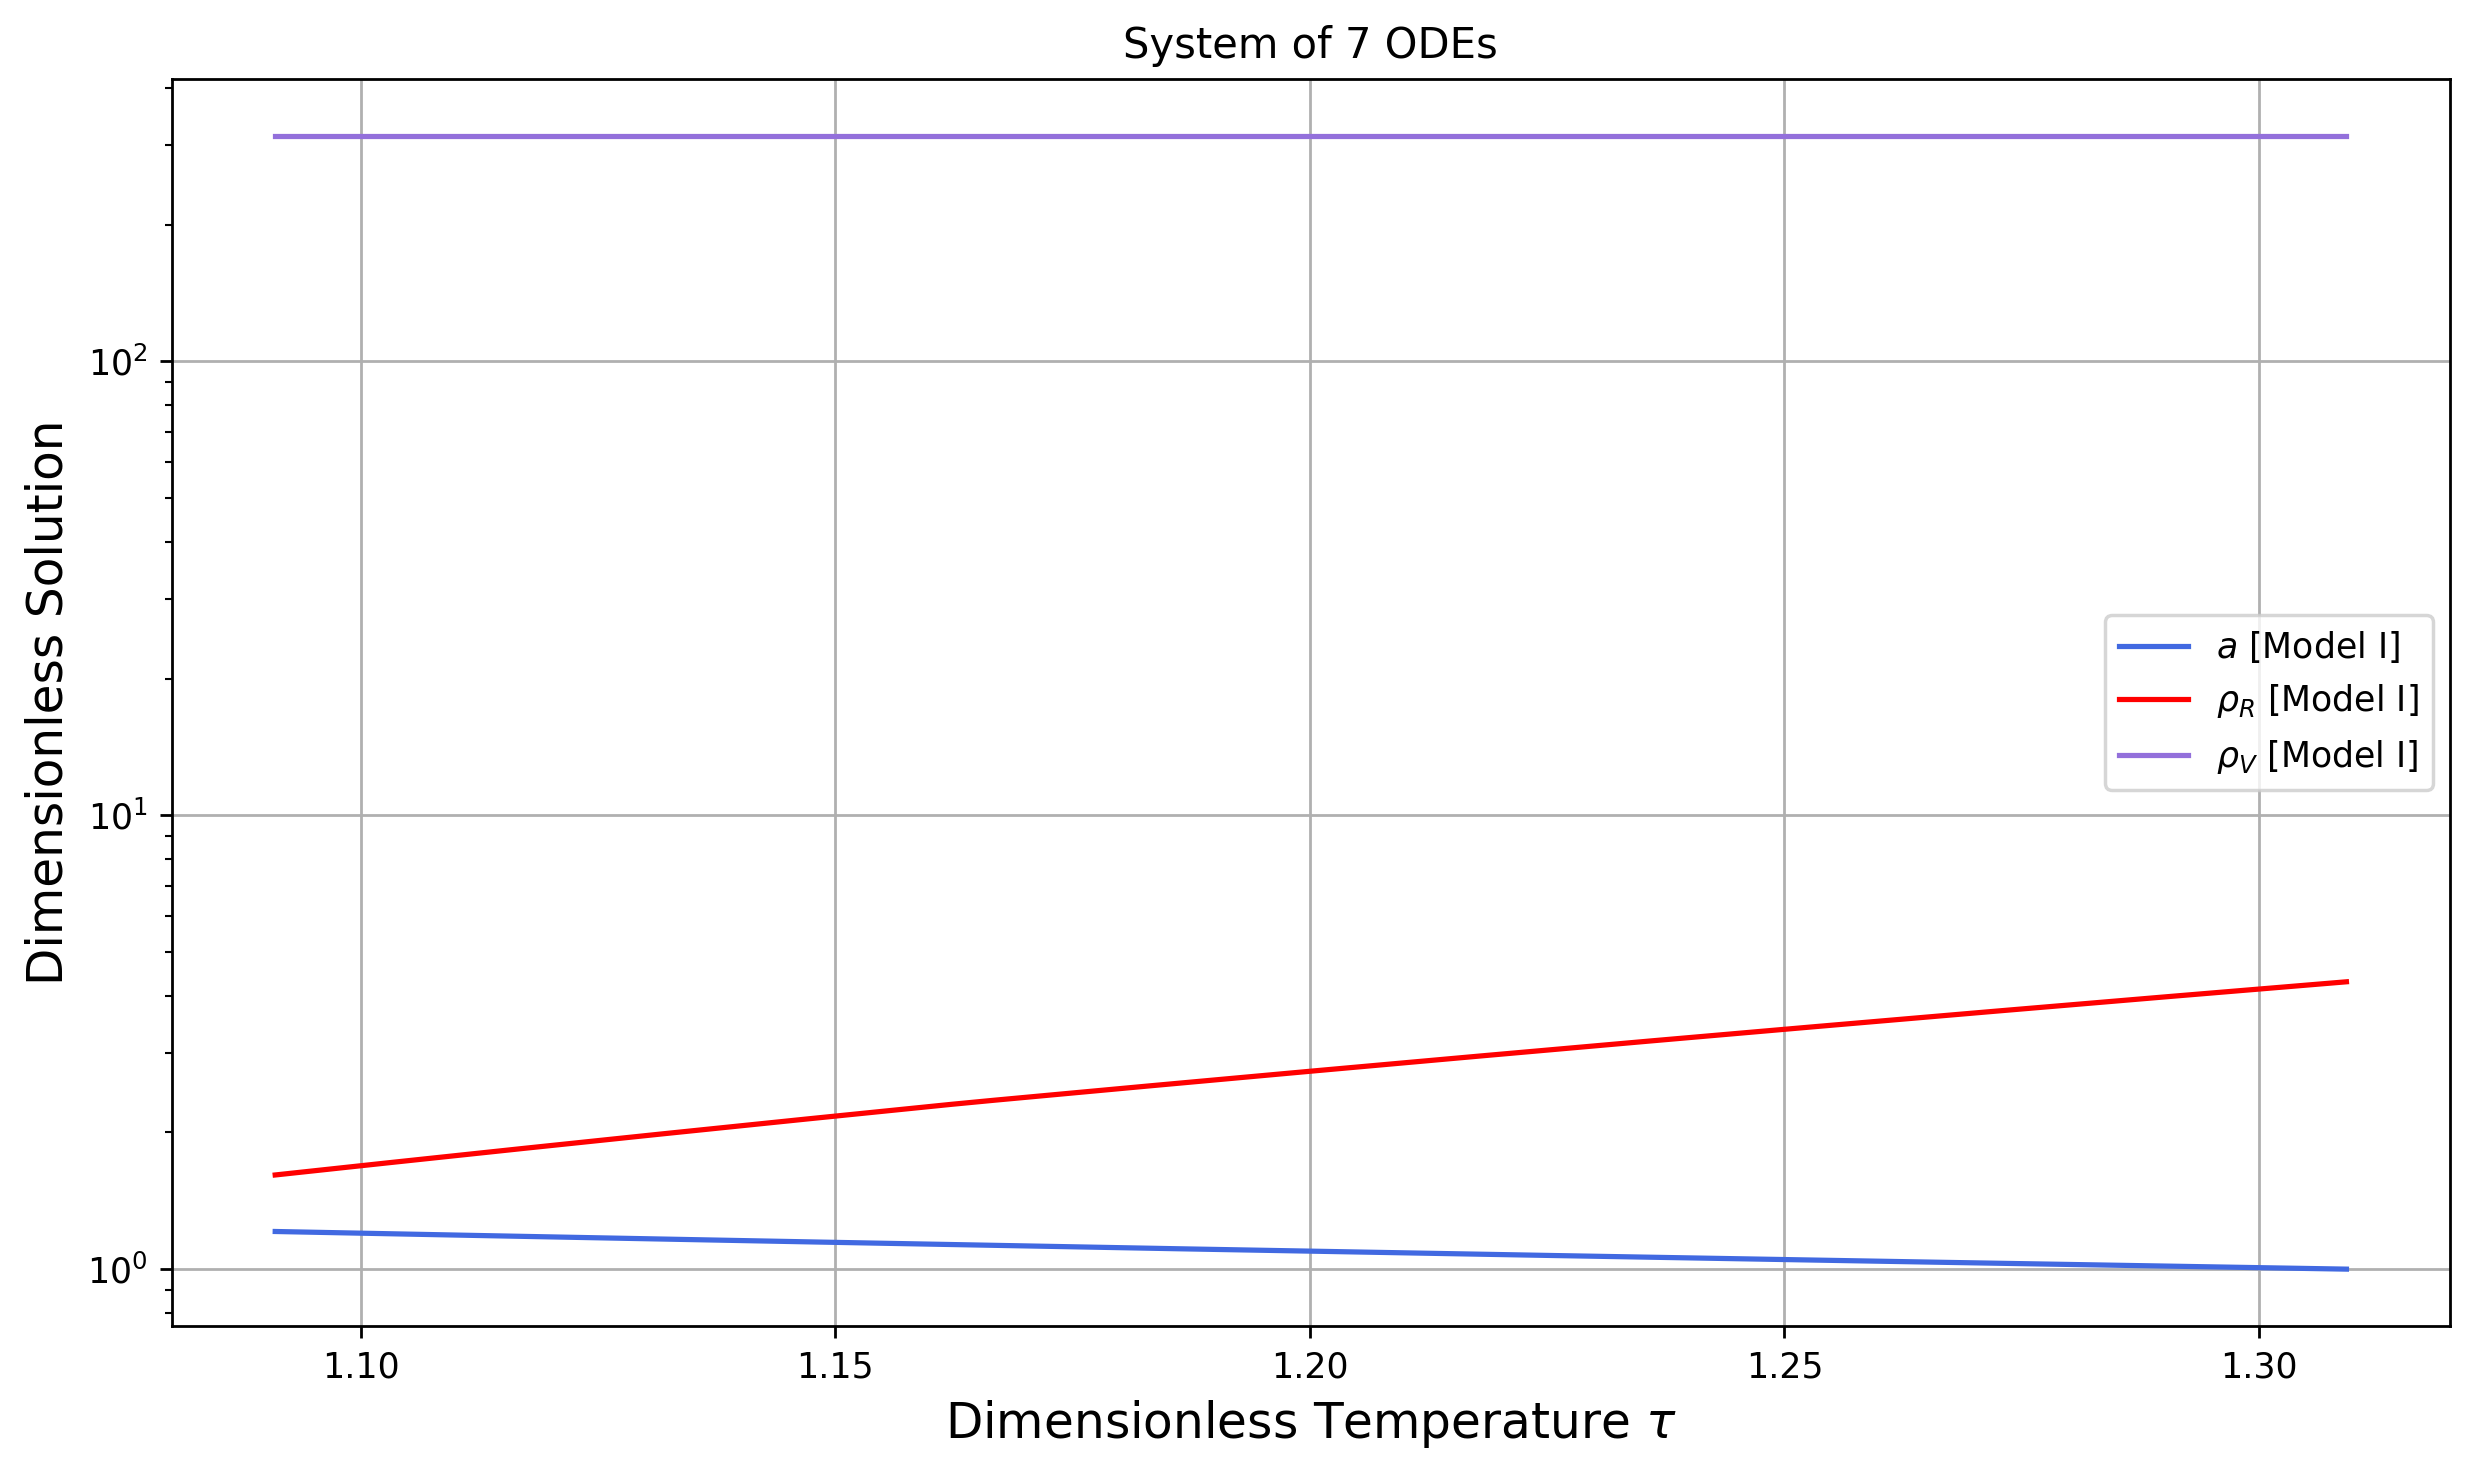

In [5]:
rhoV = CHistory.rhoV(Res.t, Res.y)

rhoR = CHistory.rhoR(Res.t)

# Plot the results
plt.figure(figsize=(10, 6), dpi=250)

plt.plot(Res.t, Res.y[0], label=r"$a$ [Model I]", color='royalblue')
plt.plot(Res.t, rhoR, label=r"$\rho_R$ [Model I]", color='r')
plt.plot(Res.t, rhoV, label=r"$\rho_V$ [Model I]", color='mediumpurple')


plt.xlabel(r'Dimensionless Temperature $\tau$', fontsize=14)
plt.ylabel('Dimensionless Solution', fontsize=14)
plt.title('System of 7 ODEs')
plt.yscale('log')
# plt.ylim((1e-3, 1e2))
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [4]:
CHistory.data[0]

[(2.160197368421053, array([1., 0., 0., 0., 0., 0.]))]

In [7]:
CHistory.tau_to_temperature(1.5271988387502924), 0.7*point['T_crit']

(np.float64(0.21508519502266715), 0.21511525541990645)

In [15]:
temp = CHistory.tau_to_temperature(1.5271988387502924 - 0.2)
temp, CHistory.bounce_action_cosmoTransitions(temp)

(np.float64(0.18691791391097232), np.float64(254.1926885410258))

In [7]:
from pypt.bubble_nucleation import *

BN = BubbleNucleationBL(Veff)
T_n = BN.TPT
print(T_n, point['T_PT'])
print(CHistory.temperature_to_tau(T_n))

0.14783897311026106 0.14783802583501146
1.049721288497947
